In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

In [2]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("shop_smart_ecommerce.csv")
# df.isnull().sum()
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [17]:
# encode
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["VisitorType"] = le.fit_transform(df["VisitorType"])
df["Weekend"] = le.fit_transform(df["Weekend"])
df["Revenue"] = le.fit_transform(df["Revenue"])
df["Month"] = le.fit_transform(df["Month"])


In [18]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,1,0


In [19]:
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

In [21]:
from sklearn.tree import DecisionTreeClassifier

X_train , X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
# print(X.dtypes)
# print(y.dtypes)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [25]:
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8526628818599622
F1 Score: 0.5321888412017167


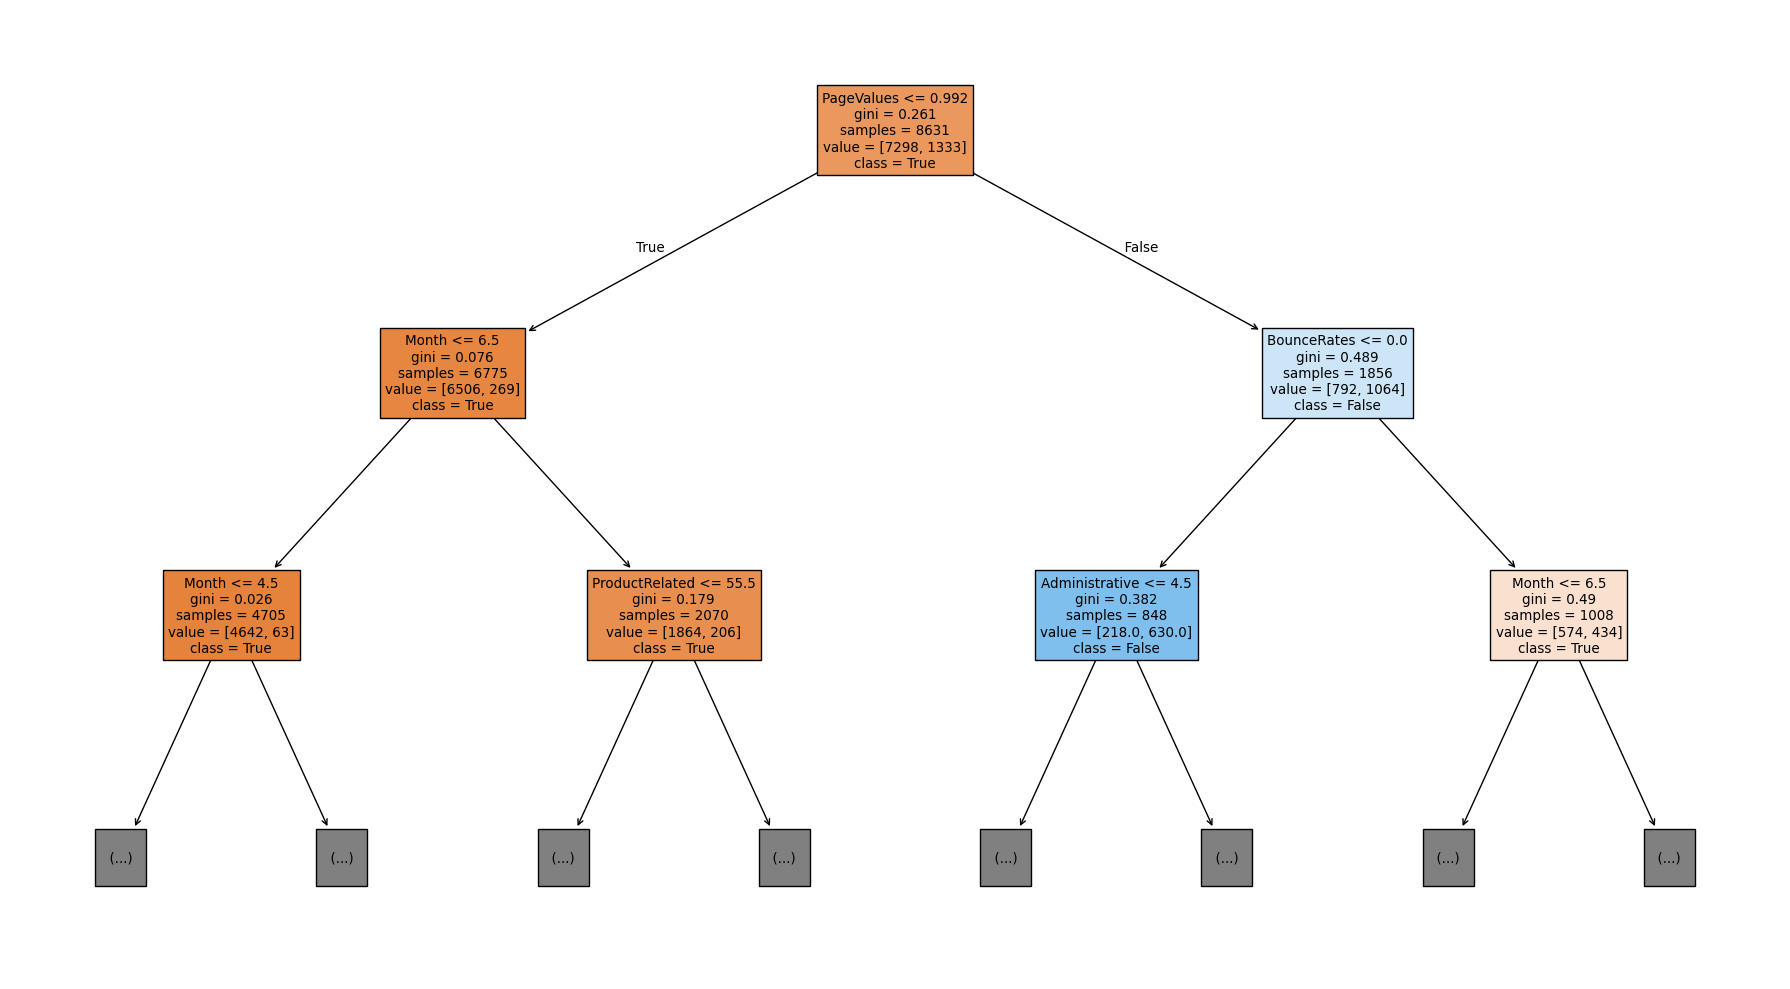

In [29]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["True", "False"],
    filled=True,
    max_depth=2
)

plt.tight_layout()
plt.show()

# Model with prepruning

In [34]:
max_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in max_depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("Depth:", depth)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print()

Depth: 2
Accuracy: 0.8837523655041903
F1 Score: 0.5305676855895196

Depth: 3
Accuracy: 0.889970262233036
F1 Score: 0.6349775784753363

Depth: 4
Accuracy: 0.8948364422816978
F1 Score: 0.593521421107628

Depth: 5
Accuracy: 0.8921330089213301
F1 Score: 0.6029850746268657

Depth: 6
Accuracy: 0.8880778588807786
F1 Score: 0.593320235756385

Depth: 7
Accuracy: 0.8875371722087051
F1 Score: 0.5929549902152642

Depth: 8
Accuracy: 0.8861854555285212
F1 Score: 0.5892682926829268

Depth: 9
Accuracy: 0.8745606920789403
F1 Score: 0.5495145631067961

Depth: 10
Accuracy: 0.8772641254393079
F1 Score: 0.5749063670411985



# Depth 3 id good

In [35]:
min_samples_splits = [5, 10, 15, 20, 25, 30]

for split in min_samples_splits:

    model = DecisionTreeClassifier(
        max_depth=3,
        min_samples_split=split,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"min_samples_split={split}")
    print(f"Accuracy = {acc:.4f}")
    print(f"F1 Score = {f1:.4f}")
    print()

min_samples_split=5
Accuracy = 0.8900
F1 Score = 0.6350

min_samples_split=10
Accuracy = 0.8900
F1 Score = 0.6350

min_samples_split=15
Accuracy = 0.8900
F1 Score = 0.6350

min_samples_split=20
Accuracy = 0.8900
F1 Score = 0.6350

min_samples_split=25
Accuracy = 0.8900
F1 Score = 0.6350

min_samples_split=30
Accuracy = 0.8900
F1 Score = 0.6350



In [ ]:
# With max_depth=3, varying min_samples_split from 5 to 30 did not change the model's performance. 

# The F1 score remained 0.6350 for all tested values. 
# Therefore, min_samples_split did not provide additional
# improvement under the current tree-depth constraint.

In [36]:
min_samples_leafs = [1, 2, 5, 10, 15, 20, 30]

for leaf in min_samples_leafs:
    model = DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=leaf,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(f"min_samples_leaf={leaf}")
    print(f"Accuracy = {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score = {f1_score(y_test, y_pred):.4f}")
    print()

min_samples_leaf=1
Accuracy = 0.8900
F1 Score = 0.6350

min_samples_leaf=2
Accuracy = 0.8900
F1 Score = 0.6350

min_samples_leaf=5
Accuracy = 0.8900
F1 Score = 0.6350

min_samples_leaf=10
Accuracy = 0.8900
F1 Score = 0.6350

min_samples_leaf=15
Accuracy = 0.8900
F1 Score = 0.6350

min_samples_leaf=20
Accuracy = 0.8900
F1 Score = 0.6350

min_samples_leaf=30
Accuracy = 0.8900
F1 Score = 0.6350



In [ ]:
# No improvment

In [37]:
max_leaf_nodes_list = [3, 5, 7, 10, 15, 20, 25, 30]

for leaves in max_leaf_nodes_list:

    model = DecisionTreeClassifier(
        max_depth=3,
        max_leaf_nodes=leaves,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(f"max_leaf_nodes={leaves}")
    print(f"Accuracy = {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score = {f1_score(y_test, y_pred):.4f}")
    print()

max_leaf_nodes=3
Accuracy = 0.8838
F1 Score = 0.5306

max_leaf_nodes=5
Accuracy = 0.8900
F1 Score = 0.6350

max_leaf_nodes=7
Accuracy = 0.8900
F1 Score = 0.6350

max_leaf_nodes=10
Accuracy = 0.8900
F1 Score = 0.6350

max_leaf_nodes=15
Accuracy = 0.8900
F1 Score = 0.6350

max_leaf_nodes=20
Accuracy = 0.8900
F1 Score = 0.6350

max_leaf_nodes=25
Accuracy = 0.8900
F1 Score = 0.6350

max_leaf_nodes=30
Accuracy = 0.8900
F1 Score = 0.6350



# Decision Tree with postpruning

In [38]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8510408218437415
F1 Score: 0.5302642796248934


In [41]:
path = model.cost_complexity_pruning_path(
    X_train,
    y_train
)

ccp_alphas = path.ccp_alphas
# print(ccp_alphas)

In [42]:
# train our model for all alphas

trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)

    trees.append((model, alpha))

In [44]:
from sklearn.metrics import f1_score

best_f1 = 0
best_alpha = 0

for model, alpha in trees:

    y_pred = model.predict(X_test)

    curr_f1 = f1_score(y_test, y_pred)

    if curr_f1 > best_f1:
        best_f1 = curr_f1
        best_alpha = alpha

print("Best F1:", best_f1)
print("Best alpha:", best_alpha)

Best F1: 0.6604046242774566
Best alpha: 0.010413172679856364


# Best alpha: 0.010413172679856364 is good

# Combination of pre and post pruning

In [45]:

model = DecisionTreeClassifier(
    max_depth=3,
    ccp_alpha=0.010413172679856364,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8837523655041903
F1 Score: 0.5305676855895196


# Result is decreased

In [46]:
alphas = [0, 0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.015, 0.02]

best_f1 = 0
best_alpha = 0

for alpha in alphas:

    model = DecisionTreeClassifier(
        max_depth=3,
        ccp_alpha=alpha,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Alpha: {alpha}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print()

    if f1 > best_f1:
        best_f1 = f1
        best_alpha = alpha

print("Best Alpha:", best_alpha)
print("Best F1:", best_f1)

Alpha: 0
Accuracy: 0.8900
F1 Score: 0.6350

Alpha: 0.0001
Accuracy: 0.8900
F1 Score: 0.6350

Alpha: 0.0005
Accuracy: 0.8900
F1 Score: 0.6350

Alpha: 0.001
Accuracy: 0.8900
F1 Score: 0.6350

Alpha: 0.002
Accuracy: 0.8900
F1 Score: 0.6350

Alpha: 0.005
Accuracy: 0.8838
F1 Score: 0.5306

Alpha: 0.01
Accuracy: 0.8838
F1 Score: 0.5306

Alpha: 0.015
Accuracy: 0.8729
F1 Score: 0.6604

Alpha: 0.02
Accuracy: 0.8729
F1 Score: 0.6604

Best Alpha: 0.015
Best F1: 0.6604046242774566


# for depth 3, aplha 0.015 is good, f1_score is 0.6604

# Optimizing alpha furthur

In [47]:
alphas = np.arange(0.010, 0.016, 0.0005)

best_f1 = 0
best_alpha = 0

for alpha in alphas:

    model = DecisionTreeClassifier(
        max_depth=3,
        ccp_alpha=alpha,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Alpha: {alpha:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print()

    if f1 > best_f1:
        best_f1 = f1
        best_alpha = alpha

print("--------------------------------")
print("Best Alpha:", best_alpha)
print("Best F1:", best_f1)

Alpha: 0.0100
Accuracy: 0.8838
F1 Score: 0.5306

Alpha: 0.0105
Accuracy: 0.8729
F1 Score: 0.6604

Alpha: 0.0110
Accuracy: 0.8729
F1 Score: 0.6604

Alpha: 0.0115
Accuracy: 0.8729
F1 Score: 0.6604

Alpha: 0.0120
Accuracy: 0.8729
F1 Score: 0.6604

Alpha: 0.0125
Accuracy: 0.8729
F1 Score: 0.6604

Alpha: 0.0130
Accuracy: 0.8729
F1 Score: 0.6604

Alpha: 0.0135
Accuracy: 0.8729
F1 Score: 0.6604

Alpha: 0.0140
Accuracy: 0.8729
F1 Score: 0.6604

Alpha: 0.0145
Accuracy: 0.8729
F1 Score: 0.6604

Alpha: 0.0150
Accuracy: 0.8729
F1 Score: 0.6604

Alpha: 0.0155
Accuracy: 0.8729
F1 Score: 0.6604

--------------------------------
Best Alpha: 0.0105
Best F1: 0.6604046242774566


In [51]:
final_model = DecisionTreeClassifier(
    ccp_alpha=0.010413172679856364,
    random_state=42
)

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Depth:", final_model.get_depth())
print("Leaves:", final_model.get_n_leaves())

Accuracy: 0.8729386320627196
F1 Score: 0.6604046242774566
Depth: 1
Leaves: 2


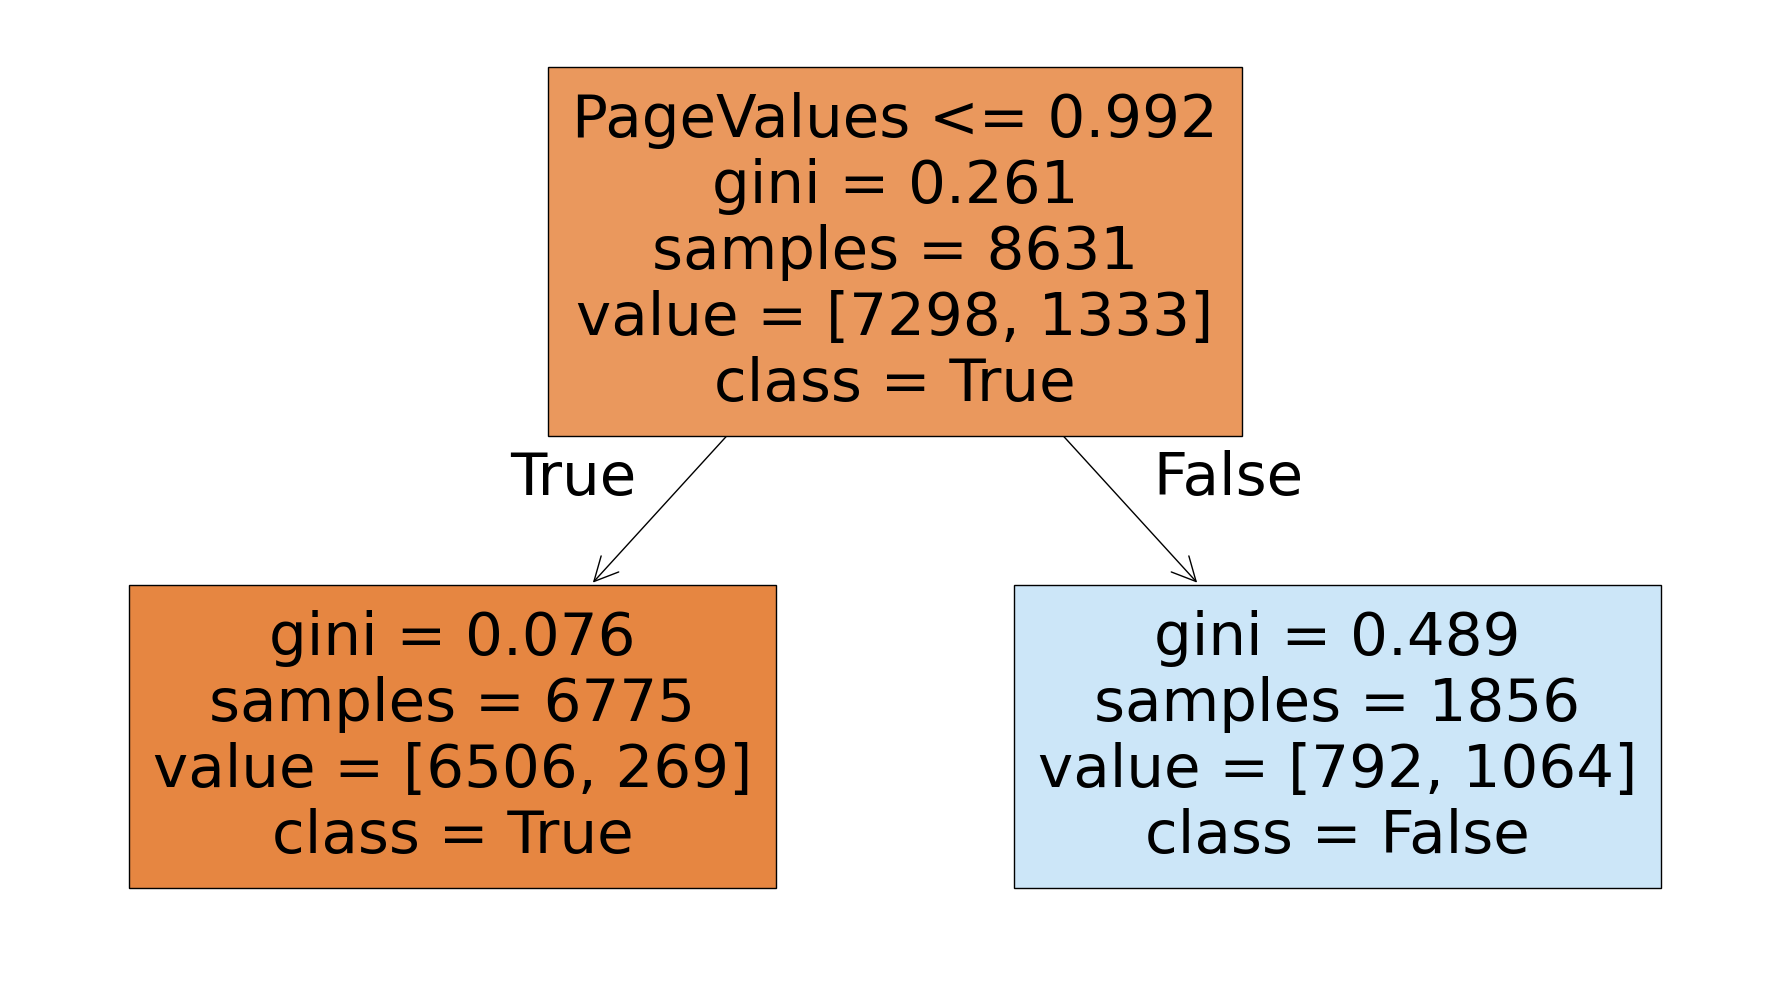

In [52]:
plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["True", "False"],
    filled=True,
)

plt.tight_layout()
plt.show()